In [1]:
# 02 배송 소요시간

In [23]:
## 01. 라이브러리 임포트
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [36]:
## 02. 데이터 불러오기
delivery_df = pd.read_csv('C:/juehyeon/aice_test/materials/datasets/delivery_time.csv')

In [37]:
delivery_df.head()

,order_amount,num_items,distance_km,rider_experience,weather,order_time,promotion_applied,delivery_time_min
0,30.18,5,6.49,medium,rain,afternoon,N,26.5
1,33.76,1,9.17,low,fog,morning,N,26.4
2,97.96,2,11.80,low,fog,night,Y,37.1
3,99.36,5,10.67,high,snow,evening,N,45.0
4,99.55,5,5.81,high,snow,night,Y,20.0


In [38]:
## 03. 데이터 시각화 barplot

<Axes: xlabel='weather', ylabel='delivery_time_min'>

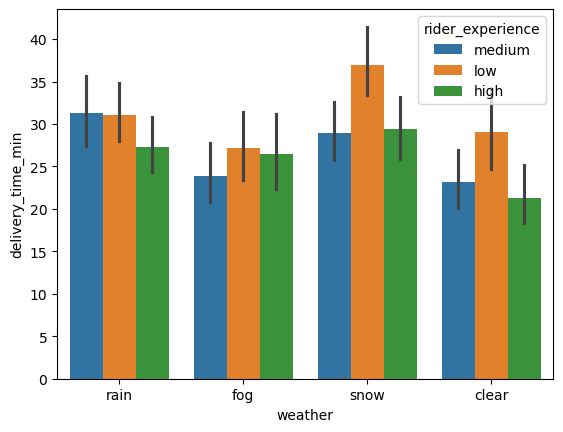

In [39]:
sns.barplot(
    data = delivery_df,
    x = 'weather',
    y = 'delivery_time_min',
    hue = 'rider_experience')

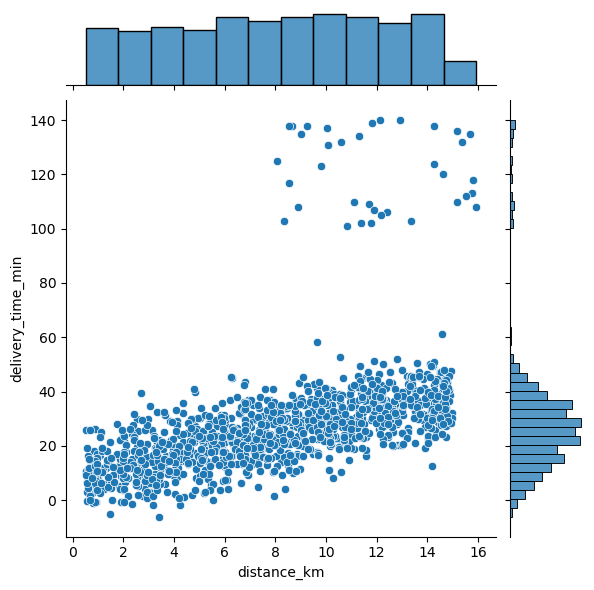

In [40]:
## 04. 이상치 제거
sns.jointplot(data = delivery_df, x = "distance_km", y = "delivery_time_min")

In [41]:
del_df = delivery_df.drop(delivery_df[delivery_df['delivery_time_min'] > 100].index, axis = 0)
del_df

,order_amount,num_items,distance_km,rider_experience,weather,order_time,promotion_applied,delivery_time_min
0,30.18,5,6.49,medium,rain,afternoon,N,26.5
1,33.76,1,9.17,low,fog,morning,N,26.4
2,97.96,2,11.80,low,fog,night,Y,37.1
3,99.36,5,10.67,high,snow,evening,N,45.0
4,99.55,5,5.81,high,snow,night,Y,20.0
...,...,...,...,...,...,...,...,...
1195,34.71,1,1.17,low,snow,night,N,19.4
1196,27.30,1,12.14,low,snow,morning,Y,38.1
1197,71.34,2,14.61,low,clear,evening,N,42.1
1198,27.79,1,7.37,low,fog,night,Y,25.3


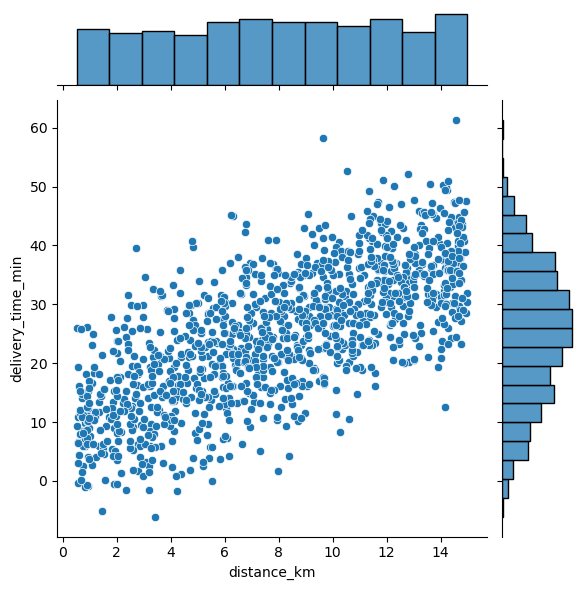

In [42]:
sns.jointplot(data = del_df, x = "distance_km", y = "delivery_time_min")

In [43]:
(del_df['delivery_time_min'] < 0).sum()

np.int64(11)

In [44]:
del_df.drop(delivery_df[delivery_df['delivery_time_min'] < 0].index, axis = 0, inplace = True)

In [45]:
del_df.reset_index(drop = True, inplace = True)
(del_df['delivery_time_min'] < 0).sum()

np.int64(0)

In [46]:
del_df.drop(columns = ['order_amount', 'num_items'], inplace = True, axis = 1)

In [48]:
del_df

,distance_km,rider_experience,weather,order_time,promotion_applied,delivery_time_min
0,6.49,medium,rain,afternoon,N,26.5
1,9.17,low,fog,morning,N,26.4
2,11.80,low,fog,night,Y,37.1
3,10.67,high,snow,evening,N,45.0
4,5.81,high,snow,night,Y,20.0
...,...,...,...,...,...,...
1148,1.17,low,snow,night,N,19.4
1149,12.14,low,snow,morning,Y,38.1
1150,14.61,low,clear,evening,N,42.1
1151,7.37,low,fog,night,Y,25.3


In [49]:
cat_col = ['rider_experience', 'weather', 'order_time']

In [50]:
encoding_df = pd.get_dummies(data = del_df, columns = cat_col, drop_first = True)

In [51]:
encoding_df

,distance_km,promotion_applied,delivery_time_min,rider_experience_low,rider_experience_medium,weather_fog,weather_rain,weather_snow,order_time_evening,order_time_morning,order_time_night
0,6.49,N,26.5,False,True,False,True,False,False,False,False
1,9.17,N,26.4,True,False,True,False,False,False,True,False
2,11.80,Y,37.1,True,False,True,False,False,False,False,True
3,10.67,N,45.0,False,False,False,False,True,True,False,False
4,5.81,Y,20.0,False,False,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...
1148,1.17,N,19.4,True,False,False,False,True,False,False,True
1149,12.14,Y,38.1,True,False,False,False,True,False,True,False
1150,14.61,N,42.1,True,False,False,False,False,True,False,False
1151,7.37,Y,25.3,True,False,True,False,False,False,False,True


In [52]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [53]:
encoding_df['promotion_applied'] = le.fit_transform(encoding_df['promotion_applied'])

In [54]:
encoding_df

,distance_km,promotion_applied,delivery_time_min,rider_experience_low,rider_experience_medium,weather_fog,weather_rain,weather_snow,order_time_evening,order_time_morning,order_time_night
0,6.49,0,26.5,False,True,False,True,False,False,False,False
1,9.17,0,26.4,True,False,True,False,False,False,True,False
2,11.80,1,37.1,True,False,True,False,False,False,False,True
3,10.67,0,45.0,False,False,False,False,True,True,False,False
4,5.81,1,20.0,False,False,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...
1148,1.17,0,19.4,True,False,False,False,True,False,False,True
1149,12.14,1,38.1,True,False,False,False,True,False,True,False
1150,14.61,0,42.1,True,False,False,False,False,True,False,False
1151,7.37,1,25.3,True,False,True,False,False,False,False,True


In [55]:
from sklearn.model_selection import train_test_split

In [56]:
X = encoding_df.drop(columns = 'delivery_time_min')
y = encoding_df['delivery_time_min']

In [57]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [59]:
## 10. 데이터 표준화
from sklearn.preprocessing import StandardScaler

In [60]:
ss = StandardScaler()

In [61]:
X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_valid)

In [62]:
from sklearn.linear_model import LinearRegression

In [63]:
lr = LinearRegression()

In [64]:
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [65]:
from sklearn.ensemble import RandomForestRegressor

In [67]:
rfr = RandomForestRegressor(n_estimators = 100, max_depth = 10, random_state = 42)

In [68]:
rfr.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False
